# XGBoost - 변수조합 ver2 (베이스라인 → 전진선택 → 후진제거)

## ver1과 뭐가 다른가
- ver1: 가설별로 사람이 미리 정한 조합 5개(+옵션1개)를 각각 통째로 비교
- ver2: **변수 하나(베이스라인)부터 시작해서, 데이터가 직접 "추가할 가치가 있는지"를 판단하며 하나씩 늘려나감(전진선택).** 그러다 변수가 너무 많아져서 모델이 복잡해지면, 반대로 하나씩 빼보면서 "빼도 성능이 거의 안 떨어지는" 변수는 제거함(후진제거) → 최종적으로 **가장 단순하면서 성능은 거의 그대로인 변수셋**을 찾는 것이 목표.

## 규칙
1. **전진선택**: 남은 후보 변수를 하나씩 추가해보고, PR-AUC가 제일 많이 오르는 걸 채택. 어떤 후보를 넣어도 PR-AUC가 `MIN_GAIN` 이상 안 오르면 종료.
2. **후진제거**: 전진선택이 끝난 변수셋에서, 하나씩 빼보고 PR-AUC 하락폭이 `MIN_GAIN` 미만(=미세한 하락)이면 그 변수는 영구 제거(모델이 단순해지므로). 더 뺄 게 없으면 종료.
3. **임계값(threshold)**: 0.90보다 높은 범위까지 스윕해서 하나로 고정하고, 이후 모든 변수조합 비교에서 **동일한 임계값**을 사용.
4. **트리 개수**: 300으로 고정하지 않고 XGBoost의 **early stopping**을 써서 검증셋 성능이 더 안 좋아지면 자동으로 멈추게 함.

## 주의 — 아직 검증 안 된 신규 변수들
`fraud_full_features.csv`에 `prior_normal_median_amt`, `amt_to_prior_median_ratio`, `is_10x_prior_median`,
`has_prior_normal_transaction`, `outside_trans_hours_80`, `merchant_change_count`, `rolling_sum_amt_1h` 등
ver1에서 안 써본 새 변수가 여러 개 추가돼 있음. 이 변수들이 **미래 정보 없이(직전 기록만으로) 안전하게 계산됐는지는
나겸님 코드를 직접 확인하지 않아서 100% 검증되진 않음** — 만약 단변량(STEP 2) 결과에서 어떤 변수 하나가
비정상적으로(예: PR-AUC 0.9 이상) 잘 나오면, "성능이 너무 좋으면 의심"(누수 가능성)부터 먼저 확인할 것.

## 예상 소요시간
후보 변수가 많아서(27개 단위) 전진선택+후진제거를 다 돌리면 XGBoost를 200~300회 이상 학습시키게 됨.
실측 기준 변수 1개짜리는 약 0.7초, 변수 40개(전체 후보)는 약 42초 걸려서, 체감상 **총 20~40분 정도**(다영님 컴퓨터 기준) 예상됨 — 한 번에 끝까지 돌려놓고 기다리는 용도로 쓸 것.


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)


## 데이터 로드 & 시간순 정렬

In [3]:
DATA_PATH = 'data/fraud_full_features.csv'

df = pd.read_csv(DATA_PATH)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

# category 원-핫 인코딩 (XGBoost가 문자열을 못 읽어서)
cat_encode_cols = [
    c for c in ['category', 'gender']
    if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
]
_cols_before = set(df.columns)
if cat_encode_cols:
    df = pd.get_dummies(df, columns=cat_encode_cols, drop_first=False)
CAT_COLS = [c for c in df.columns if c not in _cols_before]

print(df.shape)
print('원-핫으로 새로 생긴 컬럼:', CAT_COLS)


(1296675, 44)
원-핫으로 새로 생긴 컬럼: ['category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


## 후보 변수 풀 정의

`is_fraud`(정답), 식별자(trans_num, cc_num, merchant, trans_date_trans_time)를 제외한 전부를 후보로 넣음.
`category`는 원-핫 인코딩된 14개 컬럼을 **하나의 단위**로 묶어서, 전진선택/후진제거 때 통째로 추가/제거됨
(사람이 "category라는 변수"로 생각하는 방식과 맞추기 위함).

In [4]:
CANDIDATE_UNITS = {
    'amt': ['amt'],
    'recent_24h_high_amt_count': ['recent_24h_high_amt_count'],
    'category_recent_fraud_rate': ['category_recent_fraud_rate'],
    'category_recent_fraud_rate_missing': ['category_recent_fraud_rate_missing'],
    'count_30min': ['count_30min'],
    'Repeat3': ['Repeat3'],
    'high_speed': ['high_speed'],
    'speed_2': ['speed_2'],
    'customer_mean_amt': ['customer_mean_amt'],
    'customer_std_amt': ['customer_std_amt'],
    'amt_ratio_to_mean': ['amt_ratio_to_mean'],
    'amt_zscore_card': ['amt_zscore_card'],
    'customer_transaction_count': ['customer_transaction_count'],
    'trans_hour': ['trans_hour'],
    'age': ['age'],
    'prior_normal_median_amt': ['prior_normal_median_amt'],
    'amt_to_prior_median_ratio': ['amt_to_prior_median_ratio'],
    'is_10x_prior_median': ['is_10x_prior_median'],
    'has_prior_normal_transaction': ['has_prior_normal_transaction'],
    'outside_trans_hours_80': ['outside_trans_hours_80'],
    'is_online': ['is_online'],
    'risk_time_22_04': ['risk_time_22_04'],
    'interact_repeat_category': ['interact_repeat_category'],
    'merchant_change_count': ['merchant_change_count'],
    'rolling_sum_amt_1h': ['rolling_sum_amt_1h'],
    'is_high_amt': ['is_high_amt'],
    'category': CAT_COLS,
}

# 실제로 데이터셋에 없는 후보는 자동 제외 (팀 데이터가 또 바뀌어도 에러 안 나게)
missing_units = {k: v for k, v in CANDIDATE_UNITS.items() if any(c not in df.columns for c in v)}
if missing_units:
    print('[경고] 데이터셋에 없어서 제외된 후보:', list(missing_units.keys()))
    CANDIDATE_UNITS = {k: v for k, v in CANDIDATE_UNITS.items() if k not in missing_units}

print(f'총 후보 단위 수: {len(CANDIDATE_UNITS)}개')


총 후보 단위 수: 27개


## 3단계 시간순 분할

- `train_fit` : 실제로 트리를 학습시키는 데이터
- `train_val` : early stopping이 "이제 그만 멈춰"를 판단할 때 보는 데이터 (test와는 별개!)
- `test`      : 마지막에 딱 한 번만 성능을 확인하는 완전 홀드아웃

test로 early stopping을 판단하면 test 정보가 모델 설계(트리 개수)에 스며드는 셈이라, 반드시 train 안에서
따로 검증셋을 떼어내야 함.

In [5]:
n = len(df)
split_test = int(n * 0.8)
train_full_df = df.iloc[:split_test].copy()
test_df = df.iloc[split_test:].copy()

split_val = int(len(train_full_df) * 0.85)
train_fit_df = train_full_df.iloc[:split_val].copy()
train_val_df = train_full_df.iloc[split_val:].copy()

print(f'train_fit : {len(train_fit_df):,}건 (사기 {train_fit_df["is_fraud"].sum():,}건)')
print(f'train_val : {len(train_val_df):,}건 (사기 {train_val_df["is_fraud"].sum():,}건)')
print(f'test      : {len(test_df):,}건 (사기 {test_df["is_fraud"].sum():,}건)')


train_fit : 881,739건 (사기 4,989건)
train_val : 155,601건 (사기 979건)
test      : 259,335건 (사기 1,538건)


## 공통 학습 함수 (early stopping 적용)

In [6]:
EARLY_STOPPING_ROUNDS = 30
FIXED_THRESHOLD = None  # STEP 1에서 결정 후 채워짐


def fit_xgb_es(feature_list, label, threshold=None, verbose_log=True):
    X_fit, y_fit = train_fit_df[feature_list], train_fit_df['is_fraud']
    X_val, y_val = train_val_df[feature_list], train_val_df['is_fraud']
    X_test, y_test = test_df[feature_list], test_df['is_fraud']

    normal = (y_fit == 0).sum()
    fraud = (y_fit == 1).sum()
    scale_pos_weight = normal / fraud

    model = xgb.XGBClassifier(
        n_estimators=1000,          # 상한선일 뿐 - early stopping이 실제 개수를 정함
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

    proba_test = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, proba_test)
    pr_auc = average_precision_score(y_test, proba_test)

    result = {
        'label': label,
        'features': list(feature_list),
        'model': model,
        'best_iteration': model.best_iteration,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    }

    th = threshold if threshold is not None else FIXED_THRESHOLD
    if th is not None:
        pred = (proba_test >= th).astype(int)
        result['threshold'] = th
        result['precision'] = precision_score(y_test, pred, zero_division=0)
        result['recall'] = recall_score(y_test, pred, zero_division=0)
        result['f1'] = f1_score(y_test, pred, zero_division=0)

    if verbose_log:
        msg = (f"[{label}] 변수 {len(feature_list)}개 | best_iter={model.best_iteration} | "
               f"PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f}")
        if th is not None:
            msg += (f" | @{th:.2f} P={result['precision']:.4f} "
                    f"R={result['recall']:.4f} F1={result['f1']:.4f}")
        print(msg)

    return result


## STEP 1 — 임계값(threshold) 탐색 & 고정

후보 변수 전부를 넣은 "참고모델"로 0.90~0.99 구간을 스윕해서, 이후 모든 비교에 공통으로 쓸
임계값을 하나로 고정한다. (F1이 최대인 지점을 자동 추천하되, 마음에 안 들면 아래에서 직접 바꿔도 됨)

In [7]:
reference_features = []
for cols in CANDIDATE_UNITS.values():
    reference_features.extend(cols)

ref_result = fit_xgb_es(reference_features, '참고모델(전체후보)', threshold=None, verbose_log=True)

X_test_ref = test_df[reference_features]
y_test = test_df['is_fraud']
proba_ref = ref_result['model'].predict_proba(X_test_ref)[:, 1]

print('\n--- Threshold 스윕 (0.90 ~ 0.99) ---')
sweep_rows = []
for th in np.arange(0.90, 0.995, 0.01):
    th = round(float(th), 2)
    pred = (proba_ref >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    print(f'Threshold={th:.2f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')
    sweep_rows.append({'threshold': th, 'precision': p, 'recall': r, 'f1': f1})

sweep_df = pd.DataFrame(sweep_rows)
best_row = sweep_df.loc[sweep_df['f1'].idxmax()]
FIXED_THRESHOLD = round(float(best_row['threshold']), 2)
print(f"\n>> F1 기준 자동 추천 임계값: {FIXED_THRESHOLD}")
print("   (다른 값을 쓰고 싶으면 다음 줄 주석 풀고 직접 지정: FIXED_THRESHOLD = 0.95 등)")
# FIXED_THRESHOLD = 0.95


[참고모델(전체후보)] 변수 40개 | best_iter=856 | PR-AUC=0.9574 | ROC-AUC=0.9990

--- Threshold 스윕 (0.90 ~ 0.99) ---
Threshold=0.90  Precision=0.9911  Recall=0.7939  F1=0.8816
Threshold=0.91  Precision=0.9910  Recall=0.7906  F1=0.8796
Threshold=0.92  Precision=0.9918  Recall=0.7848  F1=0.8762
Threshold=0.93  Precision=0.9918  Recall=0.7822  F1=0.8746
Threshold=0.94  Precision=0.9917  Recall=0.7744  F1=0.8697
Threshold=0.95  Precision=0.9924  Recall=0.7659  F1=0.8646
Threshold=0.96  Precision=0.9932  Recall=0.7607  F1=0.8616
Threshold=0.97  Precision=0.9948  Recall=0.7510  F1=0.8559
Threshold=0.98  Precision=0.9974  Recall=0.7399  F1=0.8496
Threshold=0.99  Precision=0.9982  Recall=0.7152  F1=0.8333

>> F1 기준 자동 추천 임계값: 0.9
   (다른 값을 쓰고 싶으면 다음 줄 주석 풀고 직접 지정: FIXED_THRESHOLD = 0.95 등)


## STEP 2 — 단변량(변수 1개씩) PR-AUC 순위

모든 후보를 각각 혼자 넣었을 때 PR-AUC를 확인해서, **1등을 베이스라인으로 채택**한다.

In [8]:
print('=== STEP 2: 단변량 PR-AUC 순위 ===\n')
univariate_results = {}
for name, cols in CANDIDATE_UNITS.items():
    res = fit_xgb_es(cols, f'단변량_{name}', verbose_log=False)
    univariate_results[name] = res
    print(f"{name:35s} PR-AUC={res['pr_auc']:.4f}  ROC-AUC={res['roc_auc']:.4f}")

uni_rank = sorted(univariate_results.items(), key=lambda x: x[1]['pr_auc'], reverse=True)
print('\n--- 순위 ---')
for i, (name, res) in enumerate(uni_rank, 1):
    print(f"{i:2d}. {name:35s} PR-AUC={res['pr_auc']:.4f}")

BASELINE_VAR = uni_rank[0][0]
print(f"\n>> 베이스라인으로 채택: '{BASELINE_VAR}' (PR-AUC {uni_rank[0][1]['pr_auc']:.4f})")


=== STEP 2: 단변량 PR-AUC 순위 ===

amt                                 PR-AUC=0.2561  ROC-AUC=0.9646
recent_24h_high_amt_count           PR-AUC=0.3799  ROC-AUC=0.8429
category_recent_fraud_rate          PR-AUC=0.0139  ROC-AUC=0.7185
category_recent_fraud_rate_missing  PR-AUC=0.0059  ROC-AUC=0.5000
count_30min                         PR-AUC=0.0099  ROC-AUC=0.6302
Repeat3                             PR-AUC=0.0066  ROC-AUC=0.5094
high_speed                          PR-AUC=0.0067  ROC-AUC=0.5379
speed_2                             PR-AUC=0.0110  ROC-AUC=0.6633
customer_mean_amt                   PR-AUC=0.1192  ROC-AUC=0.5574
customer_std_amt                    PR-AUC=0.0391  ROC-AUC=0.5015
amt_ratio_to_mean                   PR-AUC=0.1655  ROC-AUC=0.8993
amt_zscore_card                     PR-AUC=0.1777  ROC-AUC=0.8990
customer_transaction_count          PR-AUC=0.1240  ROC-AUC=0.6763
trans_hour                          PR-AUC=0.0250  ROC-AUC=0.8233
age                                 PR-AUC=0.

## STEP 3 — 전진선택 (Forward Selection)

베이스라인 1개에서 시작해서, 매 라운드마다 남은 후보를 하나씩 추가해보고 **PR-AUC가 `MIN_GAIN` 이상
오르는 것 중 제일 많이 오르는 것**을 채택한다. 아무 후보도 `MIN_GAIN` 이상 못 올리면 종료.

In [9]:
print('=== STEP 3: 전진선택 ===\n')

MIN_GAIN = 0.003  # PR-AUC가 이 값 미만으로 변하면 "미세한 변화"로 취급 (원하면 조정)

selected = [BASELINE_VAR]
remaining = [name for name in CANDIDATE_UNITS if name != BASELINE_VAR]


def features_of(names):
    feats = []
    for n in names:
        feats.extend(CANDIDATE_UNITS[n])
    return feats


current_result = fit_xgb_es(features_of(selected), f"전진_라운드0({BASELINE_VAR})", verbose_log=True)
current_pr_auc = current_result['pr_auc']
forward_history = [{
    'round': 0, 'action': '베이스라인', 'changed': BASELINE_VAR,
    'features': list(selected), 'pr_auc': current_pr_auc,
}]

round_num = 0
while remaining:
    round_num += 1
    best_candidate, best_pr_auc, best_result = None, current_pr_auc, None

    print(f"\n--- 전진 라운드 {round_num}: 후보 {len(remaining)}개 테스트 ---")
    for cand in remaining:
        trial_result = fit_xgb_es(features_of(selected + [cand]), f"시도_+{cand}", verbose_log=False)
        gain = trial_result['pr_auc'] - current_pr_auc
        print(f"  + {cand:35s} PR-AUC={trial_result['pr_auc']:.4f} (변화 {gain:+.4f})")
        if trial_result['pr_auc'] > best_pr_auc:
            best_pr_auc, best_candidate, best_result = trial_result['pr_auc'], cand, trial_result

    if best_candidate is None or (best_pr_auc - current_pr_auc) < MIN_GAIN:
        print(f"\n>> 더 이상 유의미하게(+{MIN_GAIN} 이상) 개선하는 변수가 없어서 전진선택 종료")
        break

    selected.append(best_candidate)
    remaining.remove(best_candidate)
    print(f">> 채택: '{best_candidate}'  (PR-AUC {current_pr_auc:.4f} -> {best_pr_auc:.4f})")
    current_pr_auc, current_result = best_pr_auc, best_result
    forward_history.append({
        'round': round_num, 'action': '추가', 'changed': best_candidate,
        'features': list(selected), 'pr_auc': current_pr_auc,
    })

print(f"\n=== 전진선택 완료: {len(selected)}개 변수, PR-AUC={current_pr_auc:.4f} ===")
print(selected)


=== STEP 3: 전진선택 ===

[전진_라운드0(recent_24h_high_amt_count)] 변수 1개 | best_iter=0 | PR-AUC=0.3799 | ROC-AUC=0.8429 | @0.90 P=0.0000 R=0.0000 F1=0.0000

--- 전진 라운드 1: 후보 26개 테스트 ---
  + amt                                 PR-AUC=0.6865 (변화 +0.3066)
  + category_recent_fraud_rate          PR-AUC=0.4724 (변화 +0.0925)
  + category_recent_fraud_rate_missing  PR-AUC=0.3799 (변화 +0.0000)
  + count_30min                         PR-AUC=0.4291 (변화 +0.0491)
  + Repeat3                             PR-AUC=0.3847 (변화 +0.0048)
  + high_speed                          PR-AUC=0.3925 (변화 +0.0125)
  + speed_2                             PR-AUC=0.4476 (변화 +0.0677)
  + customer_mean_amt                   PR-AUC=0.4619 (변화 +0.0819)
  + customer_std_amt                    PR-AUC=0.4495 (변화 +0.0696)
  + amt_ratio_to_mean                   PR-AUC=0.6494 (변화 +0.2695)
  + amt_zscore_card                     PR-AUC=0.6551 (변화 +0.2752)
  + customer_transaction_count          PR-AUC=0.4345 (변화 +0.0545)
  + trans_hour    

## STEP 4 — 후진제거 (Backward Elimination)

전진선택 결과에서, 매 라운드마다 변수를 하나씩 빼보고 **PR-AUC 하락폭이 `MIN_GAIN` 미만(=미세한 하락)인
것 중 하락폭이 제일 작은 것**을 영구 제거한다. 어떤 걸 빼도 `MIN_GAIN` 이상 떨어지면 종료
(더 빼면 모델이 단순해지는 이득보다 성능 손해가 커진다는 뜻).

In [10]:
print('=== STEP 4: 후진제거 ===\n')

backward_history = []
round_num = 0

while True:
    round_num += 1
    if len(selected) <= 1:
        print('변수가 1개뿐이라 더 뺄 수 없음, 종료')
        break

    print(f"\n--- 후진 라운드 {round_num}: {len(selected)}개 변수 중 제거 후보 확인 ---")
    worst_candidate, smallest_drop, worst_result = None, None, None

    for cand in list(selected):
        trial_vars = [v for v in selected if v != cand]
        trial_result = fit_xgb_es(features_of(trial_vars), f"제거시도_-{cand}", verbose_log=False)
        drop = current_pr_auc - trial_result['pr_auc']
        print(f"  - {cand:35s} 제거 시 PR-AUC={trial_result['pr_auc']:.4f} (하락 {drop:+.4f})")
        if smallest_drop is None or drop < smallest_drop:
            smallest_drop, worst_candidate, worst_result = drop, cand, trial_result

    if smallest_drop is not None and smallest_drop < MIN_GAIN:
        selected.remove(worst_candidate)
        print(f">> 제거: '{worst_candidate}' (하락폭 {smallest_drop:.4f} < 기준 {MIN_GAIN} → 단순화를 위해 제거)")
        current_pr_auc, current_result = worst_result['pr_auc'], worst_result
        backward_history.append({
            'round': round_num, 'action': '제거', 'changed': worst_candidate,
            'features': list(selected), 'pr_auc': current_pr_auc,
        })
    else:
        print(f"\n>> 더 빼면 {MIN_GAIN} 이상 떨어져서 후진제거 종료")
        break

print(f"\n=== 최종 변수셋: {len(selected)}개, PR-AUC={current_pr_auc:.4f} ===")
print(selected)


=== STEP 4: 후진제거 ===


--- 후진 라운드 1: 6개 변수 중 제거 후보 확인 ---
  - recent_24h_high_amt_count           제거 시 PR-AUC=0.9043 (하락 +0.0665)
  - amt_to_prior_median_ratio           제거 시 PR-AUC=0.9646 (하락 +0.0062)
  - category                            제거 시 PR-AUC=0.8735 (하락 +0.0973)
  - amt                                 제거 시 PR-AUC=0.9359 (하락 +0.0349)
  - trans_hour                          제거 시 PR-AUC=0.9324 (하락 +0.0384)
  - age                                 제거 시 PR-AUC=0.9524 (하락 +0.0184)

>> 더 빼면 0.003 이상 떨어져서 후진제거 종료

=== 최종 변수셋: 6개, PR-AUC=0.9708 ===
['recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category', 'amt', 'trans_hour', 'age']


## STEP 5 — 최종 모델 리포트

In [11]:
FINAL_VARS = selected
FINAL_FEATURES = features_of(FINAL_VARS)

final_result = fit_xgb_es(FINAL_FEATURES, 'FINAL', threshold=FIXED_THRESHOLD, verbose_log=True)

X_test_final = test_df[FINAL_FEATURES]
y_test = test_df['is_fraud']
proba_final = final_result['model'].predict_proba(X_test_final)[:, 1]
pred_final = (proba_final >= FIXED_THRESHOLD).astype(int)

print('\n=== 최종 모델 Confusion Matrix ===')
cm = confusion_matrix(y_test, pred_final)
print(pd.DataFrame(cm, index=['실제_정상', '실제_사기'], columns=['예측_정상', '예측_사기']))

print(f"\nROC-AUC : {final_result['roc_auc']:.4f}")
print(f"PR-AUC  : {final_result['pr_auc']:.4f}")
print(f"@threshold={FIXED_THRESHOLD}  Precision={final_result['precision']:.4f}  "
      f"Recall={final_result['recall']:.4f}  F1={final_result['f1']:.4f}")
print(f"best_iteration(트리 개수, early stopping이 결정): {final_result['best_iteration']}")

importances = pd.Series(
    final_result['model'].feature_importances_, index=FINAL_FEATURES
).sort_values(ascending=False)
print('\n=== Feature Importances ===')
print(importances)

print('\n=== 최종 변수 간 상관계수 (절대값 0.5 이상만 표시 — 다중공선성 재확인) ===')
corr = test_df[FINAL_FEATURES].corr()
high_corr_pairs = []
for i in range(len(FINAL_FEATURES)):
    for j in range(i + 1, len(FINAL_FEATURES)):
        c = corr.iloc[i, j]
        if abs(c) >= 0.5:
            high_corr_pairs.append((FINAL_FEATURES[i], FINAL_FEATURES[j], round(float(c), 3)))
if high_corr_pairs:
    for a, b, c in high_corr_pairs:
        print(f"  {a} <-> {b}: {c}")
else:
    print("  0.5 이상인 쌍 없음 (다중공선성 문제 없어 보임)")


[FINAL] 변수 19개 | best_iter=774 | PR-AUC=0.9708 | ROC-AUC=0.9996 | @0.90 P=0.8868 R=0.9376 F1=0.9115

=== 최종 모델 Confusion Matrix ===
        예측_정상  예측_사기
실제_정상  257613    184
실제_사기      96   1442

ROC-AUC : 0.9996
PR-AUC  : 0.9708
@threshold=0.9  Precision=0.8868  Recall=0.9376  F1=0.9115
best_iteration(트리 개수, early stopping이 결정): 774

=== Feature Importances ===
recent_24h_high_amt_count    0.205588
amt                          0.184021
category_gas_transport       0.153962
category_grocery_net         0.067334
category_grocery_pos         0.053134
category_food_dining         0.044804
category_travel              0.041416
category_entertainment       0.037981
category_home                0.036262
category_misc_pos            0.031770
trans_hour                   0.027086
category_shopping_pos        0.025430
category_shopping_net        0.021482
amt_to_prior_median_ratio    0.018242
category_misc_net            0.018185
category_kids_pets           0.010396
category_personal_care     

## STEP 5-1 — 최종 모델(6개 변수) 자체 임계값 재스윕

STEP 1의 스윕은 전체 후보(40개 컬럼) 넣은 참고모델 기준이었음. 최종 채택된 6개 변수 모델은 확률 분포가 다를 수 있으니, 이 모델 자체로 다시 스윕해서 FIXED_THRESHOLD(0.90)보다 더 나은 지점이 있는지 확인한다.

1차: 0.10~0.95 (0.05 간격) 큰 범위로 훑고 → 2차: 1차에서 제일 좋았던 지점 주변을 0.01 간격으로 정밀 재확인.

In [12]:
print('=== 최종 모델(6개 변수) 임계값 재스윕: 1차 (0.10~0.95, 0.05 간격) ===\n')

sweep_rows_final = []
for th in np.arange(0.10, 0.96, 0.05):
    th = round(float(th), 2)
    pred = (proba_final >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    print(f'Threshold={th:.2f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')
    sweep_rows_final.append({'threshold': th, 'precision': p, 'recall': r, 'f1': f1})

sweep_final_df = pd.DataFrame(sweep_rows_final)
coarse_best = sweep_final_df.loc[sweep_final_df['f1'].idxmax()]
coarse_best_th = float(coarse_best['threshold'])
print(f"\n1차 최고점: threshold={coarse_best_th:.2f}  F1={coarse_best['f1']:.4f}")

print('\n=== 2차: 1차 최고점 주변 정밀 스윕 (0.01 간격) ===\n')
lo = max(0.01, round(coarse_best_th - 0.05, 2))
hi = min(0.99, round(coarse_best_th + 0.05, 2))
sweep_rows_fine = []
for th in np.arange(lo, hi + 0.001, 0.01):
    th = round(float(th), 2)
    pred = (proba_final >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    print(f'Threshold={th:.2f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')
    sweep_rows_fine.append({'threshold': th, 'precision': p, 'recall': r, 'f1': f1})

sweep_fine_df = pd.DataFrame(sweep_rows_fine)
best_fine = sweep_fine_df.loc[sweep_fine_df['f1'].idxmax()]

print(f"\n>> 최종 모델 기준 F1 최고 임계값: {best_fine['threshold']:.2f}  "
      f"(Precision={best_fine['precision']:.4f}  Recall={best_fine['recall']:.4f}  F1={best_fine['f1']:.4f})")
print(f">> 기존에 쓰던 FIXED_THRESHOLD={FIXED_THRESHOLD} 였음 — "
      f"{'그대로 쓰면 됨' if round(float(best_fine['threshold']),2)==FIXED_THRESHOLD else '이 값으로 바꾸는 걸 고려'}")


=== 최종 모델(6개 변수) 임계값 재스윕: 1차 (0.10~0.95, 0.05 간격) ===

Threshold=0.10  Precision=0.4667  Recall=0.9837  F1=0.6331
Threshold=0.15  Precision=0.5211  Recall=0.9792  F1=0.6802
Threshold=0.20  Precision=0.5643  Recall=0.9759  F1=0.7151
Threshold=0.25  Precision=0.5961  Recall=0.9720  F1=0.7390
Threshold=0.30  Precision=0.6260  Recall=0.9720  F1=0.7616
Threshold=0.35  Precision=0.6491  Recall=0.9694  F1=0.7776
Threshold=0.40  Precision=0.6707  Recall=0.9694  F1=0.7929
Threshold=0.45  Precision=0.6948  Recall=0.9681  F1=0.8090
Threshold=0.50  Precision=0.7163  Recall=0.9636  F1=0.8217
Threshold=0.55  Precision=0.7319  Recall=0.9623  F1=0.8315
Threshold=0.60  Precision=0.7489  Recall=0.9597  F1=0.8413
Threshold=0.65  Precision=0.7671  Recall=0.9571  F1=0.8516
Threshold=0.70  Precision=0.7840  Recall=0.9532  F1=0.8603
Threshold=0.75  Precision=0.8034  Recall=0.9512  F1=0.8711
Threshold=0.80  Precision=0.8257  Recall=0.9454  F1=0.8815
Threshold=0.85  Precision=0.8514  Recall=0.9428  F1=0.8948
T

## STEP 5-2 — 0.95~0.995 초정밀 재스윕

STEP 5-1에서 F1이 0.98~0.99 근처에서 정점을 찍은 뒤 거의 안 꺾여서, 혹시 0.99보다 더 높은 지점에 진짜 최적점이 있는지 0.005 간격으로 더 좁혀서 확인한다.

In [13]:
print('=== 최종 모델 임계값 초정밀 재스윕 (0.95~0.995, 0.005 간격) ===\n')

sweep_rows_ultra = []
for th in np.arange(0.95, 0.9951, 0.005):
    th = round(float(th), 4)
    pred = (proba_final >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    print(f'Threshold={th:.3f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')
    sweep_rows_ultra.append({'threshold': th, 'precision': p, 'recall': r, 'f1': f1})

sweep_ultra_df = pd.DataFrame(sweep_rows_ultra)
best_ultra = sweep_ultra_df.loc[sweep_ultra_df['f1'].idxmax()]
print(f"\n>> 0.95~0.995 구간 내 F1 최고 임계값: {best_ultra['threshold']:.3f}  "
      f"(Precision={best_ultra['precision']:.4f}  Recall={best_ultra['recall']:.4f}  F1={best_ultra['f1']:.4f})")

# 참고: 이 구간에서 실제 몇 건이나 잡고 놓치는지 confusion matrix로 체감하기
best_th_ultra = float(best_ultra['threshold'])
pred_ultra = (proba_final >= best_th_ultra).astype(int)
cm_ultra = confusion_matrix(y_test, pred_ultra)
print(f"\nthreshold={best_th_ultra:.3f} 기준 confusion matrix (실제 사기 {int(y_test.sum())}건 중):")
print(pd.DataFrame(cm_ultra, index=['실제_정상', '실제_사기'], columns=['예측_정상', '예측_사기']))


=== 최종 모델 임계값 초정밀 재스윕 (0.95~0.995, 0.005 간격) ===

Threshold=0.950  Precision=0.9242  Recall=0.9194  F1=0.9218
Threshold=0.955  Precision=0.9270  Recall=0.9161  F1=0.9215
Threshold=0.960  Precision=0.9348  Recall=0.9135  F1=0.9240
Threshold=0.965  Precision=0.9408  Recall=0.9090  F1=0.9246
Threshold=0.970  Precision=0.9425  Recall=0.9064  F1=0.9241
Threshold=0.975  Precision=0.9475  Recall=0.9044  F1=0.9255
Threshold=0.980  Precision=0.9545  Recall=0.8999  F1=0.9264
Threshold=0.985  Precision=0.9650  Recall=0.8953  F1=0.9288
Threshold=0.990  Precision=0.9749  Recall=0.8823  F1=0.9263
Threshold=0.995  Precision=0.9845  Recall=0.8654  F1=0.9211

>> 0.95~0.995 구간 내 F1 최고 임계값: 0.985  (Precision=0.9650  Recall=0.8953  F1=0.9288)

threshold=0.985 기준 confusion matrix (실제 사기 1538건 중):
        예측_정상  예측_사기
실제_정상  257747     50
실제_사기     161   1377


## STEP 5-3 — 0.90 / 0.985 / 0.990 3개 임계값 최종 비교

재학습 필요 없음(PR-AUC 기준 변수선택 결과는 임계값과 무관하므로, 이미 학습된 최종 모델의 확률(`proba_final`)만 다시 잘라서 비교). 발표자료용으로 confusion matrix까지 한 번에 정리.

In [14]:
compare_thresholds = [0.90, 0.985, 0.990]

print('=== 임계값별 최종 비교 (변수 6개는 동일, 자르는 기준선만 다름) ===\n')
compare_rows = []
for th in compare_thresholds:
    pred = (proba_final >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    print(f'--- threshold={th:.3f} ---')
    print(pd.DataFrame(cm, index=['실제_정상', '실제_사기'], columns=['예측_정상', '예측_사기']))
    print(f'Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}  (잡은 사기 {tp}건 / 놓친 사기 {fn}건 / 오탐 {fp}건)\n')

    compare_rows.append({
        'threshold': th, 'precision': round(p, 4), 'recall': round(r, 4), 'f1': round(f1, 4),
        '잡은사기(TP)': tp, '놓친사기(FN)': fn, '오탐(FP)': fp,
    })

compare_df = pd.DataFrame(compare_rows)
print('=== 요약표 ===')
print(compare_df.to_string(index=False))


=== 임계값별 최종 비교 (변수 6개는 동일, 자르는 기준선만 다름) ===

--- threshold=0.900 ---
        예측_정상  예측_사기
실제_정상  257613    184
실제_사기      96   1442
Precision=0.8868  Recall=0.9376  F1=0.9115  (잡은 사기 1442건 / 놓친 사기 96건 / 오탐 184건)

--- threshold=0.985 ---
        예측_정상  예측_사기
실제_정상  257747     50
실제_사기     161   1377
Precision=0.9650  Recall=0.8953  F1=0.9288  (잡은 사기 1377건 / 놓친 사기 161건 / 오탐 50건)

--- threshold=0.990 ---
        예측_정상  예측_사기
실제_정상  257762     35
실제_사기     181   1357
Precision=0.9749  Recall=0.8823  F1=0.9263  (잡은 사기 1357건 / 놓친 사기 181건 / 오탐 35건)

=== 요약표 ===
 threshold  precision  recall     f1  잡은사기(TP)  놓친사기(FN)  오탐(FP)
     0.900     0.8868  0.9376 0.9115      1442        96     184
     0.985     0.9650  0.8953 0.9288      1377       161      50
     0.990     0.9749  0.8823 0.9263      1357       181      35


## STEP 5-4 — 팀 제출용 후보 4개 준비

팀에서 "모델당 후보를 2~5개까지 넓게 가져오자"(validation 과적합 안전장치)고 했으므로, 전진선택 과정에서 이미 나온 라운드별 결과(3개/4개/5개 변수 버전)를 후보 2~4위로 재사용한다. 완전히 새로운 조합을 찾는 게 아니라, PR-AUC가 이미 검증된 상위 라운드들을 그대로 가져오는 것 — 혹시 최종(6개 변수) 모델이 validation에 과적합이었다면, 더 단순한 이 후보들이 대신 안정적일 수 있음.

후보1(최종, 6개 변수)은 이미 있으니 재학습 없음. 후보2~4(5개/4개/3개 변수)만 재학습해서 0.90/0.985/0.990 3개 임계값 전부 비교.

In [15]:
print('=== 팀 제출용 후보 2~4위 모델 준비 (전진선택 라운드별 결과 재사용) ===\n')

candidate_defs = {
    '후보1_최종(6개변수)': {'unit_names': FINAL_VARS, 'result': final_result},
}

# forward_history 인덱스: [0]=베이스라인(1개), [1]=2개, [2]=3개, [3]=4개, [4]=5개, [5]=최종(6개)
extra_rounds = {
    '후보2_5개변수': forward_history[4],
    '후보3_4개변수': forward_history[3],
    '후보4_3개변수': forward_history[2],
}

for name, hist in extra_rounds.items():
    feats = features_of(hist['features'])
    result = fit_xgb_es(feats, name, threshold=FIXED_THRESHOLD, verbose_log=True)
    candidate_defs[name] = {'unit_names': hist['features'], 'result': result}

print('\n=== 후보별 변수 구성 & 3개 임계값 비교 ===\n')
all_compare_rows = []
for cand_name, info in candidate_defs.items():
    result = info['result']
    model = result['model']
    feats = result['features']
    proba = model.predict_proba(test_df[feats])[:, 1]

    print(f"\n########## {cand_name} \u2014 PR-AUC {result['pr_auc']:.4f} ##########")
    print('변수:', info['unit_names'])

    for th in [0.90, 0.985, 0.990]:
        pred = (proba >= th).astype(int)
        p = precision_score(y_test, pred, zero_division=0)
        r = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)
        cm = confusion_matrix(y_test, pred)
        tn, fp, fn, tp = cm.ravel()
        print(f'  threshold={th:.3f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}  '
              f'(잡은사기{tp}/놓친사기{fn}/오탐{fp})')
        all_compare_rows.append({
            '후보': cand_name, '변수개수': len(feats), 'PR-AUC': round(result['pr_auc'], 4),
            'threshold': th, 'precision': round(p, 4), 'recall': round(r, 4), 'f1': round(f1, 4),
            '잡은사기': tp, '놓친사기': fn, '오탐': fp,
        })

final_compare_df = pd.DataFrame(all_compare_rows)
print('\n=== 전체 비교표 (팀 제출용, 후보 4개 x 임계값 3개 = 12행) ===')
print(final_compare_df.to_string(index=False))


=== 팀 제출용 후보 2~4위 모델 준비 (전진선택 라운드별 결과 재사용) ===

[후보2_5개변수] 변수 18개 | best_iter=469 | PR-AUC=0.9524 | ROC-AUC=0.9993 | @0.90 P=0.7063 R=0.9350 F1=0.8047
[후보3_4개변수] 변수 17개 | best_iter=470 | PR-AUC=0.9301 | ROC-AUC=0.9988 | @0.90 P=0.5612 R=0.9480 F1=0.7050
[후보4_3개변수] 변수 16개 | best_iter=342 | PR-AUC=0.8614 | ROC-AUC=0.9955 | @0.90 P=0.5251 R=0.8901 F1=0.6606

=== 후보별 변수 구성 & 3개 임계값 비교 ===


########## 후보1_최종(6개변수) — PR-AUC 0.9708 ##########
변수: ['recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category', 'amt', 'trans_hour', 'age']
  threshold=0.900  Precision=0.8868  Recall=0.9376  F1=0.9115  (잡은사기1442/놓친사기96/오탐184)
  threshold=0.985  Precision=0.9650  Recall=0.8953  F1=0.9288  (잡은사기1377/놓친사기161/오탐50)
  threshold=0.990  Precision=0.9749  Recall=0.8823  F1=0.9263  (잡은사기1357/놓친사기181/오탐35)

########## 후보2_5개변수 — PR-AUC 0.9524 ##########
변수: ['recent_24h_high_amt_count', 'amt_to_prior_median_ratio', 'category', 'amt', 'trans_hour']
  threshold=0.900  Precision=0.7063  Recall=0.9350 

## STEP 6 — 선택 과정 전체 요약표 (발표자료용)

In [16]:
history_rows = []
for h in forward_history:
    history_rows.append({
        '단계': h['action'], '라운드': h['round'], '변경된 변수': h['changed'],
        '변수 개수': len(h['features']), 'PR-AUC': round(h['pr_auc'], 4),
    })
for h in backward_history:
    history_rows.append({
        '단계': h['action'], '라운드': h['round'], '변경된 변수': f"- {h['changed']}",
        '변수 개수': len(h['features']), 'PR-AUC': round(h['pr_auc'], 4),
    })

hist_df = pd.DataFrame(history_rows)
print(hist_df.to_string(index=False))

print(f"\n최종 변수 {len(FINAL_VARS)}개:")
for v in FINAL_VARS:
    print(' -', v)


   단계  라운드                    변경된 변수  변수 개수  PR-AUC
베이스라인    0 recent_24h_high_amt_count      1  0.3799
   추가    1 amt_to_prior_median_ratio      2  0.7082
   추가    2                  category      3  0.8614
   추가    3                       amt      4  0.9301
   추가    4                trans_hour      5  0.9524
   추가    5                       age      6  0.9708

최종 변수 6개:
 - recent_24h_high_amt_count
 - amt_to_prior_median_ratio
 - category
 - amt
 - trans_hour
 - age


## (보너스) 최종 모델 SHAP 해석

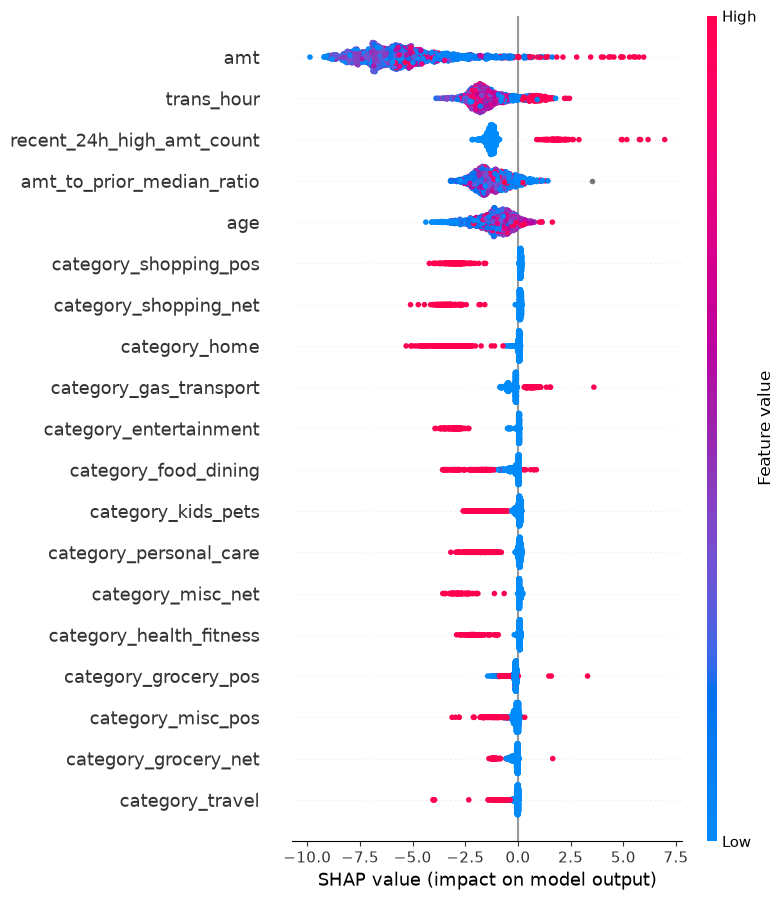

In [17]:
explainer = shap.TreeExplainer(final_result['model'])
X_test_sample = test_df[FINAL_FEATURES].sample(min(2000, len(test_df)), random_state=42)
shap_values = explainer(X_test_sample)

shap.summary_plot(shap_values, X_test_sample, show=True)
